# CUADERNO JUPYTER UNIFICADO: Práctica 1 – Metaheurísticas (Curso 2025/2026)
## Simulated Annealing (SA)

## 1. Introducción

El objetivo de esta práctica es segmentar una serie temporal en *k* segmentos, ajustando en cada uno de ellos una regresión lineal independiente. La calidad de una segmentación se evalúa mediante el **RMSE medio** de todos los segmentos, que actúa como función objetivo a minimizar.

En este cuaderno se implementa el algoritmo **Simulated Annealing (SA)**, una metaheurística inspirada en el proceso físico de recocido de metales. SA permite escapar de óptimos locales aceptando soluciones peores con una probabilidad controlada por la temperatura.

Simulated Annealing sigue una estrategia más flexible que Hill Climbing:

- Parte de una solución inicial aleatoria.  
- Genera soluciones vecinas modificando los puntos de corte.  
- Acepta soluciones peores con una probabilidad dependiente de la temperatura.  
- Reduce la temperatura según una función de enfriamiento.  
- Busca equilibrar exploración (temperaturas altas) y explotación (temperaturas bajas).


## 2. Importación de librerías

En esta sección se importan las librerías necesarias para:

- Cálculo numérico (`numpy`)
- Visualización (`matplotlib`)
- Ajuste de regresiones lineales (`sklearn`)
- Gestión de datos (`pandas`)
- Medición del error (`mean_squared_error`)
- Generación de números aleatorios
- Funciones matemáticas (`math`)
- Medición de tiempos

Estas herramientas permiten implementar y evaluar el algoritmo Simulated Annealing.

In [1]:
from enum import Flag
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import random
import math
import time
from tabulate import tabulate


## 3. Carga de series temporales

Se define una función auxiliar para leer los archivos de datos que contienen las series temporales TS1–TS4.  
Cada archivo contiene una lista de valores numéricos entre corchetes, por lo que es necesario limpiarlos antes de convertirlos a `float`.

Posteriormente, se cargan las cuatro series y se asocian con sus valores de *k* correspondientes:

- TS1 → k = 9  
- TS2 → k = 10  
- TS3 → k = 20  
- TS4 → k = 50  

Estas series serán utilizadas en los experimentos posteriores.


In [2]:
def read_serie(path):
    with open(path, "r") as f:
        contenido = f.read().replace("[", "").replace("]", "").split()
    return [float(x) for x in contenido]

files = ["../datos/TS1", "../datos/TS2", "../datos/TS3", "../datos/TS4"]
series = [read_serie(f) for f in files]
k_values = [9, 10, 20, 50]

print("Series cargadas correctamente")

Series cargadas correctamente


## 4. Regresión lineal por segmentos

Para evaluar la calidad de una segmentación, SA necesita calcular el RMSE medio de los segmentos.  
Para ello se implementan funciones que permiten ajustar una regresión lineal a cada segmento.

### `estimate_segment_coef(x, y)`
Ajusta una recta mediante `scikit-learn`.

### `estimate_coef(x, y)`
Calcula los coeficientes de forma manual usando fórmulas estadísticas.

### `estimate_all_coef(temp, points)`
Calcula los coeficientes de todos los segmentos definidos por los puntos de corte.

### `estimate_all_points(coef, points, temp_size)`
Reconstruye la serie estimada completa a partir de los coeficientes de cada segmento.

Estas funciones permiten evaluar la calidad de una segmentación.


In [3]:
def estimate_segment_coef(x, y):
    x = np.array(x).reshape(-1, 1)
    y = np.array(y)
    if len(x) < 2:
        return (0.0, 0.0)
    model = LinearRegression().fit(x, y)
    return (model.coef_[0], model.intercept_)


def estimate_coef(x, y):
    x = np.array(x)
    y = np.array(y)
    n = np.size(x)

    if n == 0:
        return (0.0, 0.0)

    m_x = np.mean(x)
    m_y = np.mean(y)

    SS_xy = np.sum(y * x) - n * m_y * m_x
    SS_xx = np.sum(x * x) - n * m_x * m_x

    if abs(SS_xx) < 1e-8:
        b_0 = 0.0
        b_1 = m_y
    else:
        b_0 = SS_xy / SS_xx
        b_1 = m_y - b_0 * m_x

    return (float(b_0), float(b_1))


def estimate_all_coef(temp, points):
    coef = []
    start = 0

    pts = points.copy()
    pts.append(len(temp))

    for point in pts:
        b_0, b_1 = estimate_coef(range(start, point), temp[start:point])
        coef.append((b_0, b_1))
        start = point

    return coef


def estimate_point(coef, i):
    return i * coef[0] + coef[1]


def estimate_all_points(coef, points, temp_size):
    estimated = []
    start = 0

    pts = points.copy()
    pts.append(temp_size)

    for pos, point in enumerate(pts):
        for i in range(start, point):
            estimated.append(estimate_point(coef[pos], i))
        start = point

    return estimated

## 5. Generación de puntos de corte aleatorios

La función `randomPoints` genera una solución inicial aleatoria para Simulated Annealing.  
Los puntos de corte se generan sin repetición y ordenados, garantizando que los segmentos sean válidos.


In [4]:
def randomPoints(longitud_serie, n_cortes):
    b = []
    while n_cortes > 0:
        r = random.randint(1, longitud_serie - 1)
        if r not in b:
            b.append(r)
            n_cortes -= 1
    b.sort()
    return b

## 6. Cálculo del RMSE por segmentos

Para evaluar la calidad de una segmentación se utiliza el **RMSE medio** de todos los segmentos.

### `RMSE(y_real, y_pred)`
Calcula el error cuadrático medio entre valores reales y estimados.

### `mean_rmse(serie, points)`
Calcula el RMSE medio de todos los segmentos definidos por los puntos de corte.

Este valor es la función objetivo que Simulated Annealing intenta minimizar.


In [5]:
def RMSE(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    return np.sqrt(mse)


def mean_rmse(serie, points):
    rmse_acc = 0.0
    start = 0
    coef = estimate_all_coef(serie, points.copy())
    estimated = estimate_all_points(coef, points.copy(), len(serie))
    pts = points.copy()
    pts.append(len(serie))
    for point in pts:
        rmse_acc += RMSE(serie[start:point], estimated[start:point])
        start = point
    return rmse_acc / len(pts)

## 6. Implementación del algoritmo Simulated Annealing (SA)

Simulated Annealing es una metaheurística inspirada en el proceso físico de recocido de metales.  
El algoritmo parte de una solución inicial aleatoria y explora su vecindario aceptando:

- Soluciones mejores (siempre)
- Soluciones peores (con cierta probabilidad)

La probabilidad de aceptar soluciones peores depende de la **temperatura**, que se va reduciendo progresivamente según una función de enfriamiento.

Este mecanismo permite a SA escapar de óptimos locales y explorar regiones del espacio de soluciones que otros métodos, como Hill Climbing, no pueden alcanzar.


## 6.1 Funciones de enfriamiento

La temperatura controla la probabilidad de aceptar soluciones peores.  
A medida que avanza el algoritmo, la temperatura debe disminuir para favorecer la explotación.

En este cuaderno se implementan tres funciones de enfriamiento:

### Enfriamiento lineal

$$
T_{i+1} = T_0 - i \cdot p
$$

### Enfriamiento exponencial

$$
T_{i+1} = T_0 \cdot p^i
$$

### Enfriamiento logarítmico

$$
T_{i+1} = \frac{T_0}{1 + \log(i)}
$$

Cada una de estas funciones afecta de forma distinta al equilibrio entre exploración y explotación.


In [6]:
enfriamiento_lineal = lambda T, T0, i, p: T0 - (i * p)
enfriamiento_exponencial = lambda T, T0, i, p: T0 * p**i
enfriamiento_logaritmico = lambda T, T0, i, p: T0 / (1 + math.log(i))

## 6.2 Generación de vecinos

Para explorar el espacio de soluciones, SA necesita generar soluciones vecinas a la actual.

Un vecino se obtiene modificando uno de los puntos de corte en ±1% del tamaño de la serie, respetando:

- Que ningún punto sea 0  
- Que ningún punto sea igual a la longitud total  
- Que los puntos estén estrictamente ordenados  
- Que no existan duplicados  
- Que no aparezcan segmentos vacíos  

Este proceso garantiza que todos los vecinos representan segmentaciones válidas.


In [7]:
def random_neighbour(points, n):
    neighbour = []
    flag = True

    while flag:
        neighbour = points.copy()
        neighbour[random.randint(0, len(neighbour) - 1)] += random.choice(
            (-1, 1)
        ) * int(n / 50)

        if neighbour[0] <= 0:
            continue
        if neighbour[-1] >= n:
            continue
        if sorted(neighbour) != neighbour:
            continue
        if len(set(neighbour)) != len(neighbour):
            continue
        flag = False

    return neighbour

## 6.3 Algoritmo Simulated Annealing

El algoritmo completo sigue los siguientes pasos:

1. Generar una solución inicial aleatoria.  
2. Calcular su RMSE.  
3. Mientras la temperatura sea mayor que el umbral final:
   - Generar un vecino aleatorio.
   - Calcular su RMSE.
   - Si mejora, aceptar la solución.
   - Si empeora, aceptarla con probabilidad:
    
$$
 P = e^{-\Delta / T}
$$

   - Actualizar la temperatura según la función de enfriamiento.
4. Devolver la mejor solución encontrada.

El algoritmo devuelve:
- La mejor segmentación encontrada  
- Su RMSE  
- El tiempo total de ejecución  


In [8]:
def simulated_annealing(T0, funcion_enfriamiento, p, L, Tf, serie, k):
    startTime = time.time()

    T = T0
    sol = randomPoints(len(serie), k)
    rmse_sol = mean_rmse(serie, sol)
    best = sol.copy()
    rmse_best = rmse_sol
    iter = 1

    while T >= Tf:
        for _ in range(L):
            vecino = random_neighbour(sol, len(serie))
            rmse_vecino = mean_rmse(serie, vecino)

            delta = rmse_vecino - rmse_sol

            if delta < 0 or random.uniform(0, 1) < math.exp(-delta / max(T, 1e-8)):
                sol = vecino
                rmse_sol = rmse_vecino

                if rmse_sol < rmse_best:
                    best = sol.copy()
                    rmse_best = rmse_sol

        T = funcion_enfriamiento(T, T0, iter, p)
        iter += 1

    endTime = time.time()
    return {"rmse": rmse_best, "points": best}, endTime - startTime

## 7. Ejecución del experimento completo

Para evaluar el rendimiento del algoritmo, se ejecuta Simulated Annealing:

- 20 veces por cada serie temporal  
- Probando distintos valores de los parámetros:
  - Función de enfriamiento  
  - Parámetro *p*  
  - Número de iteraciones internas *L*  
  - Temperaturas inicial y final  

En cada repetición se almacena:

- El RMSE final  
- Los puntos de corte óptimos  
- El tiempo de ejecución  

Estos datos permiten analizar cómo afectan los parámetros al rendimiento del algoritmo.


In [9]:
def ejecutar_experimento(
    series,
    k_values,
    nombre,
    funcion_enfriamiento,
    p=None,
    T0=100,
    Tf=0.1,
):
    print(f"\n=== Ejecutando SA con enfriamiento {nombre} ===")

    mean_bests = []
    mean_times = []

    for i in range(20):
        series_bests = []
        series_times = []
        for TS in range(len(series)):

            current_serie = series[TS]
            current_k = k_values[TS]


            best, time_exec = simulated_annealing(
                T0=T0,
                funcion_enfriamiento=funcion_enfriamiento,
                L=50,
                Tf=Tf,
                serie=current_serie,
                k=current_k,
                p=p)

            series_bests.append(best)
            series_times.append(time_exec)
        print(f"Repetición {i + 1}/{20} completada")

        mean_bests.append(series_bests)
        mean_times.append(series_times)

    print("=== Experimento finalizado ===")
    return mean_bests, mean_times


def ejecutar_experimento_p(
    series,
    k_values,
    nombre,
    funcion_enfriamiento,
    pi=1,
    pf=200,
    step=20,
    T0=100,
    Tf=0.1,
    L=20,
):
    print(f"\n=== Ejecutando SA con enfriamiento {nombre} ===")

    mean_bests = []
    mean_times = []
    p=[]
    for i in range(20):
        series_bests = []
        series_times = []
        for TS in range(len(series)):

            current_serie = series[TS]
            current_k = k_values[TS]
            
            bests=[]
            times=[]
            for p_val in range(pi,pf,step):
                best, time_exec = simulated_annealing(
                    T0=T0,
                    funcion_enfriamiento=funcion_enfriamiento,
                    L=L,
                    Tf=Tf,
                    serie=current_serie,
                    k=current_k,
                    p=p_val)
                bests.append(best)
                times.append(time_exec)
                if TS==0 and i==0:
                    p.append(p_val)

            series_bests.append(bests)
            series_times.append(times)
        print(f"Repetición {i + 1}/{20} completada")

        mean_bests.append(series_bests)
        mean_times.append(series_times)

    print("=== Experimento finalizado ===")
    return mean_bests, mean_times,p

def ejecutar_experimento_L(
    series,
    k_values,
    nombre,
    funcion_enfriamiento,
    Li=10,
    Lf=100,
    p=200,
    step=20,
    T0=100,
    Tf=0.1,
    L=20,
):
    print(f"\n=== Ejecutando SA con enfriamiento {nombre} ===")

    mean_bests = []
    mean_times = []
    L=[]
    for i in range(20):
        series_bests = []
        series_times = []
        for TS in range(len(series)):

            current_serie = series[TS]
            current_k = k_values[TS]
            
            bests=[]
            times=[]
            for L_val in range(Li,Lf,step):
                best, time_exec = simulated_annealing(
                    T0=T0,
                    funcion_enfriamiento=funcion_enfriamiento,
                    L=L_val,
                    Tf=Tf,
                    serie=current_serie,
                    k=current_k,
                    p=p)
                bests.append(best)
                times.append(time_exec)
                if TS==0 and i==0:
                    L.append(L_val)

            series_bests.append(bests)
            series_times.append(times)
        print(f"Repetición {i + 1}/{20} completada")

        mean_bests.append(series_bests)
        mean_times.append(series_times)

    print("=== Experimento finalizado ===")
    return mean_bests, mean_times,L

## 7.1 Funciones auxiliares para experimentos

Se implementan funciones que permiten:

- Ejecutar SA con diferentes funciones de enfriamiento  
- Probar distintos valores del parámetro *p*  
- Evaluar el efecto del número de iteraciones internas *L*  
- Analizar el impacto de las temperaturas inicial y final  

Estas funciones automatizan la experimentación y permiten generar tablas comparativas.


In [10]:
def create_Table_Lambda(bests_lin, times_lin,bests_exp, times_exp,bests_log, times_log):
    rows=[]
    bests=[]
    bests.append(bests_lin)
    bests.append(bests_exp)
    bests.append(bests_log)

    times=[]
    times.append(times_lin)
    times.append(times_exp)
    times.append(times_log)

    names=["Lineal","Exponencial","Logaritmico"]

    for N_val in range(len(names)):
        for TS in range(len(bests[0][0])):
            rmse = [bests[N_val][rep][TS]["rmse"] for rep in range(len(bests[0]))]
            time = [times[N_val][rep][TS] for rep in range(len(bests))]
            rows.append({
                "Enfriamiento": names[N_val],
                "Serie": f"Serie {TS + 1}",
                "RMSE Medio": np.mean(rmse),
                "RMSE Desv": np.std(rmse),
                "Tiempo Medio (s)": np.mean(time)
            })



    tabla = pd.DataFrame(rows)
    print(tabulate(tabla, headers="keys", tablefmt="fancy_grid", showindex=False))



def create_Table_p(bests, times, p):
    rows=[]
    for p_val in range(len(p)):
        for TS in range(len(bests[0])):
            rmse = [bests[rep][TS][p_val]["rmse"] for rep in range(len(bests))]
            time = [times[rep][TS][p_val] for rep in range(len(bests))]
            rows.append({
                "p": p[p_val],
                "Serie": f"Serie {TS + 1}",
                "RMSE Medio": np.mean(rmse),
                "RMSE Desv": np.std(rmse),
                "Tiempo Medio (s)": np.mean(time)
            })


    
    tabla = pd.DataFrame(rows)
    print(tabulate(tabla, headers="keys", tablefmt="fancy_grid", showindex=False))


def create_Table_L(bests, times, L):
    rows=[]
    for L_val in range(len(L)):
        for TS in range(len(bests[0])):
            rmse = [bests[rep][TS][L_val]["rmse"] for rep in range(len(bests))]
            time = [times[rep][TS][L_val] for rep in range(len(bests))]
            rows.append({
                "L": L[L_val],
                "Serie": f"Serie {TS + 1}",
                "RMSE Medio": np.mean(rmse),
                "RMSE Desv": np.std(rmse),
                "Tiempo Medio (s)": np.mean(time)
            })



    tabla = pd.DataFrame(rows)
    print(tabulate(tabla, headers="keys", tablefmt="fancy_grid", showindex=False))

def create_Table_T(bests, times, T0,Tf):
    rows=[]
    for TS in range(len(bests[0])):
        rmse = [bests[rep][TS]["rmse"] for rep in range(len(bests))]
        time = [times[rep][TS] for rep in range(len(bests))]
        rows.append({
        "T0": T0,
        "Tf": Tf,
        "Serie": f"Serie {TS + 1}",
        "RMSE Medio": np.mean(rmse),
        "RMSE Desv": np.std(rmse),
        "Tiempo Medio (s)": np.mean(time)
        })
    tabla = pd.DataFrame(rows)
    print(tabulate(tabla, headers="keys", tablefmt="fancy_grid", showindex=False))

In [11]:
def SA_Lambda(series, k_values):
    bests_exp, times_exp = ejecutar_experimento(
        series, k_values, "exponencial", enfriamiento_exponencial, p=0.5, Tf=1
    )

    bests_log, times_log = ejecutar_experimento(
        series, k_values, "logaritmico", enfriamiento_logaritmico, Tf=20
    )

    bests_lin, times_lin = ejecutar_experimento(
        series, k_values, "lineal", enfriamiento_lineal, p=10, Tf=20
    )

    create_Table_Lambda(bests_lin, times_lin, bests_exp, times_exp, bests_log, times_log)

    return bests_lin, times_lin, bests_exp, times_exp, bests_log, times_log

def SA_p(series, k_values):
    pi = int(input("P inicial: "))
    pf = int(input("P final: "))
    step = int(input("Incremento: "))

    bests, times, p = ejecutar_experimento_p(
        series, k_values, "p", enfriamiento_lineal, pf=pf, pi=pi, step=step
    )

    create_Table_p(bests, times, p)

    return bests, times, p

def SA_L(series, k_values):
    Li = int(input("L inicial: "))
    Lf = int(input("L final: "))
    step = int(input("Incremento: "))

    bests, times, L = ejecutar_experimento_L(
        series, k_values, "L", enfriamiento_lineal, Lf=Lf, Li=Li, step=step
    )

    create_Table_L(bests, times, L)

    return bests, times, L


def SA_T(series, k_values):
    T0 = float(input("T inicial: "))
    Tf = float(input("T final: "))
    p = float(input("Valor de p (enfriamiento lineal): "))

    bests, times = ejecutar_experimento(
        series, k_values, "T", enfriamiento_lineal, p=p, Tf=Tf, T0=T0
    )

    create_Table_T(bests, times, T0, Tf)

    return bests, times


## 8. Ejecución secuencial de todas las configuraciones de Simulated Annealing

En este apartado se ejecutan de forma automática las distintas variantes del algoritmo Simulated Annealing (SA), probando diferentes configuraciones de sus parámetros principales.  
El objetivo es analizar cómo afectan estos parámetros al rendimiento del algoritmo en términos de RMSE, estabilidad y tiempo de cómputo.

Las opciones ejecutadas son:

1. **Cambiar la función de enfriamiento λ**  
   - Se comparan los esquemas lineal, exponencial y logarítmico.

2. **Cambiar el número de iteraciones internas L**  
   - Se evalúa cómo influye el número de vecinos explorados por nivel de temperatura.

3. **Cambiar las temperaturas inicial y final (T₀ / T_f)**  
   - Se estudia el impacto del rango térmico en la exploración del espacio de soluciones.

4. **Cambiar el parámetro p del enfriamiento lineal**  
   - Se analiza cómo la velocidad de enfriamiento afecta a la aceptación de soluciones peores.

Cada opción se ejecuta 20 veces para cada serie temporal, registrando:

- El **RMSE final**  
- La **desviación típica**  
- El **tiempo medio de ejecución**  

Estos resultados permiten comparar de forma sistemática el comportamiento de SA bajo diferentes configuraciones y facilitan su posterior comparación con Random Search y Hill Climbing.

In [12]:
# Lista de opciones que quieres ejecutar una debajo de otra
opciones = ["1", "2", "3", "4"]

# Guardar resultados de cada opción de SA
resultados_lambda = None
resultados_L = None
resultados_T = None
resultados_p = None

print("=== EJECUCIÓN SECUENCIAL DE TODAS LAS OPCIONES DE SA ===")

for opcion in opciones:
    print(f"\n--- Ejecutando opción {opcion} ---")

    if opcion == "1":
        print(">> Cambiar lambda")
        resultados_lambda = SA_Lambda(series, k_values)

    elif opcion == "2":
        print(">> Cambiar número de iteraciones L")
        resultados_L = SA_L(series, k_values)

    elif opcion == "3":
        print(">> Cambiar temperatura T0 / Tf")
        resultados_T = SA_T(series, k_values)

    elif opcion == "4":
        print(">> Cambiar p en el enfriamiento lineal")
        resultados_p = SA_p(series, k_values)

print("\n=== FIN DE EJECUCIÓN ===")p


=== EJECUCIÓN SECUENCIAL DE TODAS LAS OPCIONES DE SA ===

--- Ejecutando opción 1 ---
>> Cambiar lambda

=== Ejecutando SA con enfriamiento exponencial ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
=== Experimento finalizado ===

=== Ejecutando SA con enfriamiento logaritmico ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 compl

L inicial:  10
L final:  100
Incremento:  10



=== Ejecutando SA con enfriamiento L ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
=== Experimento finalizado ===
╒═════╤═════════╤══════════════╤═════════════╤════════════════════╕
│   L │ Serie   │   RMSE Medio │   RMSE Desv │   Tiempo Medio (s) │
╞═════╪═════════╪══════════════╪═════════════╪════════════════════╡
│  10 │ Serie 1 │     0.787846 │   0.0975197 │         0.00971241 │
├─────┼─────────┼──────────────┼─────────────┼────────────────────┤
│  10 │ Serie 2 │     1.04267  │   0

T inicial:  100
T final:  20
Valor de p (enfriamiento lineal):  10



=== Ejecutando SA con enfriamiento T ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
=== Experimento finalizado ===
╒══════╤══════╤═════════╤══════════════╤═════════════╤════════════════════╕
│   T0 │   Tf │ Serie   │   RMSE Medio │   RMSE Desv │   Tiempo Medio (s) │
╞══════╪══════╪═════════╪══════════════╪═════════════╪════════════════════╡
│  100 │   20 │ Serie 1 │     0.629217 │   0.0631359 │           0.57695  │
├──────┼──────┼─────────┼──────────────┼─────────────┼──────────────────

P inicial:  1
P final:  50
Incremento:  5



=== Ejecutando SA con enfriamiento p ===
Repetición 1/20 completada
Repetición 2/20 completada
Repetición 3/20 completada
Repetición 4/20 completada
Repetición 5/20 completada
Repetición 6/20 completada
Repetición 7/20 completada
Repetición 8/20 completada
Repetición 9/20 completada
Repetición 10/20 completada
Repetición 11/20 completada
Repetición 12/20 completada
Repetición 13/20 completada
Repetición 14/20 completada
Repetición 15/20 completada
Repetición 16/20 completada
Repetición 17/20 completada
Repetición 18/20 completada
Repetición 19/20 completada
Repetición 20/20 completada
=== Experimento finalizado ===
╒═════╤═════════╤══════════════╤═════════════╤════════════════════╕
│   p │ Serie   │   RMSE Medio │   RMSE Desv │   Tiempo Medio (s) │
╞═════╪═════════╪══════════════╪═════════════╪════════════════════╡
│   1 │ Serie 1 │     0.560856 │   0.0461921 │          1.60317   │
├─────┼─────────┼──────────────┼─────────────┼────────────────────┤
│   1 │ Serie 2 │     0.831626 │   0

# 9 Selección de la mejor configuración de Simulated Annealing (SA)

En esta celda se define la función `mejor_configuracion_SA`, cuyo objetivo es identificar,
para cada serie temporal, cuál de las tres configuraciones de SA evaluadas
(enfriamiento lineal, exponencial y logarítmico) ofrece el mejor rendimiento.

La función:
- Recorre las 4 series temporales.
- Calcula el **RMSE medio** de cada configuración a lo largo de las 20 repeticiones.
- Selecciona la configuración con menor RMSE medio para cada serie.
- Obtiene las métricas finales:
  - RMSE medio.
  - Desviación típica del RMSE.
  - Tiempo medio de ejecución.

El resultado final son tres listas de longitud 4 (una por serie), que resumen el
comportamiento óptimo de SA en cada caso.

In [13]:
def mejor_configuracion_SA(bests_list, times_list):
    """
    bests_list = [bests_lin, bests_exp, bests_log]
    times_list = [times_lin, times_exp, times_log]

    Estructura:
    bests_lin[rep][TS] -> best de esa serie en esa repetición
    """
    num_series = len(bests_list[0][0])   # 4 series
    num_configs = len(bests_list)        # 3 configuraciones

    rmse_medios = []
    rmse_desv = []
    tiempos_medios = []

    for TS in range(num_series):
        mejor_rmse = float("inf")
        mejor_idx = None

        # Buscar mejor configuración para esta serie
        for config in range(num_configs):
            rmse_vals = [bests_list[config][rep][TS]["rmse"] for rep in range(len(bests_list[0]))]
            rmse_mean = np.mean(rmse_vals)

            if rmse_mean < mejor_rmse:
                mejor_rmse = rmse_mean
                mejor_idx = config

        # Métricas finales para la mejor configuración
        rmse_vals = [bests_list[mejor_idx][rep][TS]["rmse"] for rep in range(len(bests_list[0]))]
        time_vals = [times_list[mejor_idx][rep][TS] for rep in range(len(times_list[0]))]

        rmse_medios.append(np.mean(rmse_vals))
        rmse_desv.append(np.std(rmse_vals))
        tiempos_medios.append(np.mean(time_vals))

    return rmse_medios, rmse_desv, tiempos_medios


## 9.1. Obtención de métricas y resultados unificados de SA

En esta celda se agrupan los resultados obtenidos en la opción *Cambiar lambda*,
que contiene las tres configuraciones de enfriamiento evaluadas:

- Enfriamiento lineal.
- Enfriamiento exponencial.
- Enfriamiento logarítmico.

A partir de estos resultados se construyen dos listas:
- `bests_total`: mejores soluciones por configuración.
- `times_total`: tiempos de ejecución por configuración.

Finalmente, se llama a `mejor_configuracion_SA` para obtener, para cada serie temporal:
- El **RMSE medio**.
- La **desviación típica**.
- El **tiempo medio**.

Estos valores representan el rendimiento óptimo de SA para cada serie.

In [14]:
# Unificar configuraciones
bests_total = [resultados_lambda[0], resultados_lambda[2], resultados_lambda[4]]
times_total = [resultados_lambda[1], resultados_lambda[3], resultados_lambda[5]]

rmse_medios_SA, rmse_desv_SA, tiempos_medios_SA = mejor_configuracion_SA(
    bests_total, times_total
)

## 9.2. Tabla final de resultados de Simulated Annealing

En esta celda se construye un DataFrame con los resultados finales de SA para cada
serie temporal, utilizando las métricas obtenidas previamente:

- **RMSE medio**: mide la calidad de la predicción.
- **Desviación típica**: refleja la estabilidad del algoritmo.
- **Tiempo medio (s)**: indica el coste computacional.

Posteriormente, los valores se formatean para mejorar su legibilidad y se muestra
la tabla en formato `fancy_grid`, facilitando su inclusión en la memoria del proyecto.


In [15]:
tabla_SA = pd.DataFrame({
    "Serie": ["TS1 (k=9)", "TS2 (k=10)", "TS3 (k=20)", "TS4 (k=50)"],
    "RMSE medio": rmse_medios_SA,
    "Desviación típica": rmse_desv_SA,
    "Tiempo medio (s)": tiempos_medios_SA,
})
tabla_formateada_SA = tabla_SA.copy()
tabla_formateada_SA["RMSE medio"] = tabla_formateada_SA["RMSE medio"].map("{:.6f}".format)
tabla_formateada_SA["Desviación típica"] = tabla_formateada_SA["Desviación típica"].map("{:.6f}".format)
tabla_formateada_SA["Tiempo medio (s)"] = tabla_formateada_SA["Tiempo medio (s)"].map("{:.6f}".format)

print(tabulate(tabla_formateada_SA, headers="keys", tablefmt="fancy_grid", showindex=False))


╒════════════╤══════════════╤═════════════════════╤════════════════════╕
│ Serie      │   RMSE medio │   Desviación típica │   Tiempo medio (s) │
╞════════════╪══════════════╪═════════════════════╪════════════════════╡
│ TS1 (k=9)  │     0.538846 │            0.050846 │            2.19629 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS2 (k=10) │     0.791252 │            0.058433 │            2.50287 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS3 (k=20) │     0.754423 │            0.03491  │            4.78798 │
├────────────┼──────────────┼─────────────────────┼────────────────────┤
│ TS4 (k=50) │     1.09674  │            0.067147 │           11.0395  │
╘════════════╧══════════════╧═════════════════════╧════════════════════╛


# 10 Obtención de los puntos de corte óptimos en Simulated Annealing

Esta función identifica, para cada serie temporal, cuál de las tres configuraciones de SA
(enfriamiento lineal, exponencial y logarítmico) obtiene el mejor rendimiento medio en términos
de RMSE.

El proceso seguido es:

1. Para cada serie, se calcula el RMSE medio de cada configuración.
2. Se selecciona la configuración con menor RMSE medio.
3. Dentro de esa configuración, se elige la repetición que obtuvo el RMSE más bajo.
4. Se extraen los puntos de corte (`points`) de esa repetición, que representan la mejor segmentación encontrada por SA.

El resultado final es una lista con los puntos de corte óptimos para cada serie, que permite
reconstruir la serie estimada y generar la gráfica final de SA.


In [16]:
def obtener_mejores_puntos_SA(bests_list):
    """
    bests_list = [bests_lin, bests_exp, bests_log]
    Devuelve los puntos de corte óptimos para cada serie.
    """
    num_series = len(bests_list[0][0])
    num_configs = len(bests_list)

    mejores_points = []

    for TS in range(num_series):
        mejor_rmse = float("inf")
        mejor_idx = None

        # Elegir la mejor configuración para esta serie
        for config in range(num_configs):
            rmse_vals = [bests_list[config][rep][TS]["rmse"] for rep in range(len(bests_list[0]))]
            rmse_mean = np.mean(rmse_vals)

            if rmse_mean < mejor_rmse:
                mejor_rmse = rmse_mean
                mejor_idx = config

        # Elegir la repetición con menor RMSE dentro de la mejor configuración
        rep_mejor = np.argmin([bests_list[mejor_idx][rep][TS]["rmse"] for rep in range(len(bests_list[0]))])

        mejores_points.append(bests_list[mejor_idx][rep_mejor][TS]["points"])

    return mejores_points


# 11 Visualización de la mejor segmentación obtenida por Simulated Annealing

Esta función genera la gráfica final de SA para cada serie temporal, mostrando:

- La serie real (en azul).
- La serie estimada a partir de los segmentos óptimos (en rojo).
- Las líneas verticales que indican los puntos de corte seleccionados por SA.

Para cada serie:

1. Se toman los puntos de corte óptimos obtenidos previamente.
2. Se calculan los coeficientes de regresión lineal por segmentos.
3. Se reconstruye la serie estimada completa.
4. Se representa visualmente la segmentación final.

Esta gráfica es equivalente a las generadas en RS y HC, y permite incluir en la memoria
la comparación visual de la mejor configuración de SA.


In [17]:
def plot_final_SA(series, mejores_points, k_values):
    for idx, serie in enumerate(series):
        points = mejores_points[idx]

        coef = estimate_all_coef(serie, points.copy())
        estimada = estimate_all_points(coef, points.copy(), len(serie))

        plt.figure(figsize=(12, 5))
        plt.plot(serie, label="Serie real", color="blue")
        plt.plot(estimada, label="Serie estimada (SA óptimo)", color="red")

        for p in points:
            plt.axvline(x=p, linestyle="--", color="black", alpha=0.7)

        plt.title(f"Mejor configuración SA - TS{idx+1} (k={k_values[idx]})")
        plt.xlabel("Tiempo")
        plt.ylabel("Valor")
        plt.legend()
        plt.grid(True)
        plt.savefig(f"SA_TS{idx+1}_solucion_final.png", dpi=150)
        plt.show()


# 12  Ejecución final: obtención de puntos óptimos y generación de gráficas

En este bloque se:

1. Unifican las tres configuraciones evaluadas de SA (lineal, exponencial y logarítmica).
2. Obtienen los puntos de corte óptimos mediante la función `obtener_mejores_puntos_SA`.
3. Generan las gráficas finales de la serie real frente a la estimada usando `plot_final_SA`.

Estas gráficas completan el análisis visual de SA y permiten integrarlas en la memoria
junto a las de RS y HC.

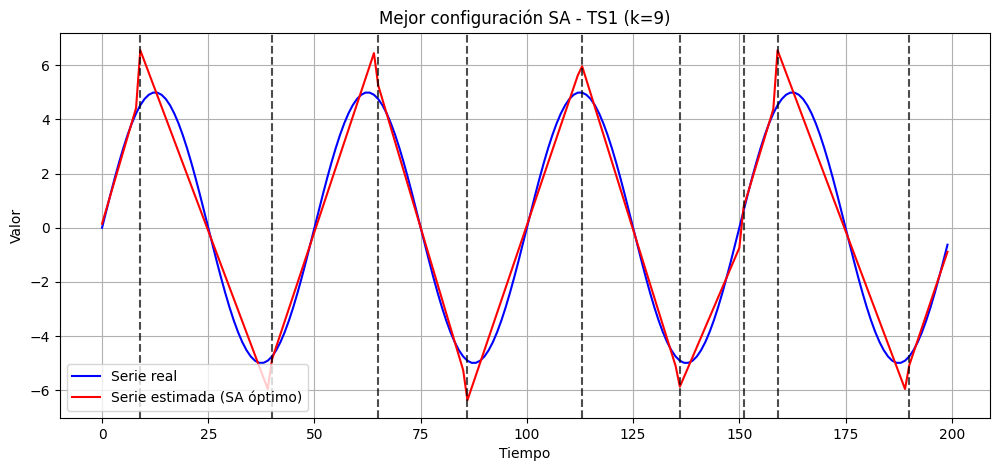

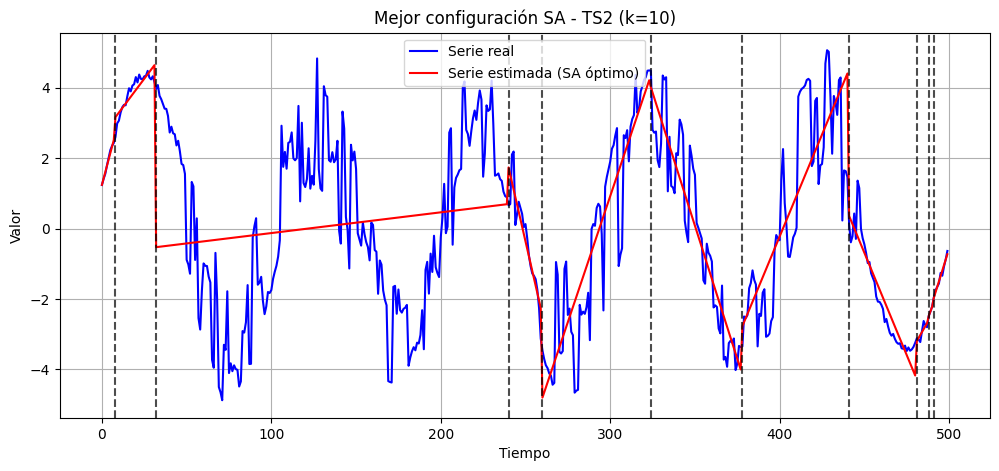

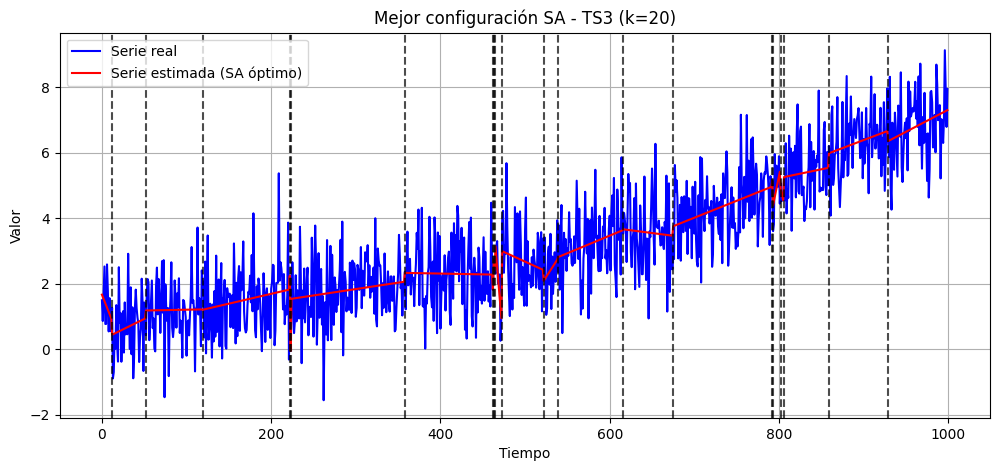

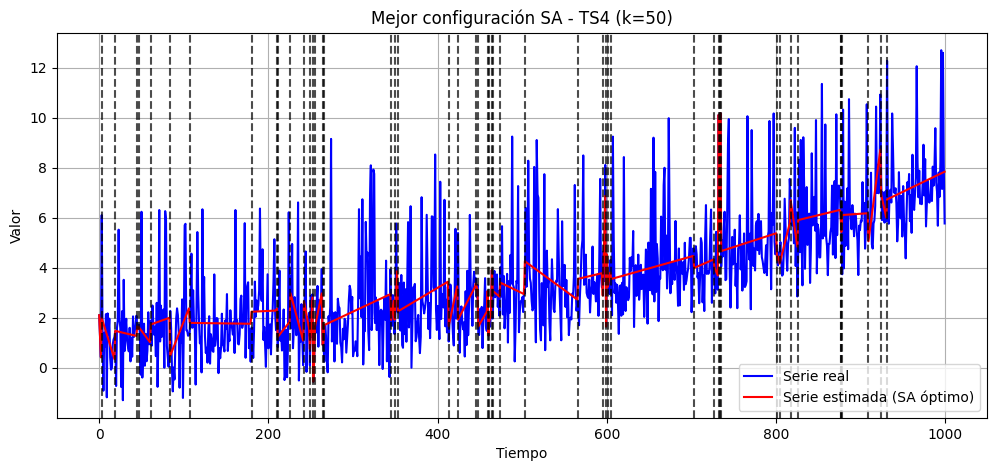

In [18]:
# Unificar configuraciones de SA
bests_total = [resultados_lambda[0], resultados_lambda[2], resultados_lambda[4]]

# Obtener puntos óptimos
mejores_points = obtener_mejores_puntos_SA(bests_total)

# Dibujar gráficas finales
plot_final_SA(series, mejores_points, k_values)
